In [ ]:
import os
import zipfile
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

In [ ]:
old_name = "/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana.zip"
new_name = "/content/anemia_dataset.zip"
os.rename(old_name, new_name)

In [ ]:

zip_path = "/content/anemia_dataset.zip"
extract_path = "/content/anemia_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)


Files extracted to: /content/anemia_dataset


In [ ]:
all_images = []
for root, dirs, files in os.walk(extract_path):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            all_images.append(os.path.join(root, f))

print("Number of images:", len(all_images))
print("Sample:", all_images[0])

Number of images: 4262
Sample: /content/anemia_dataset/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-075 (3).png


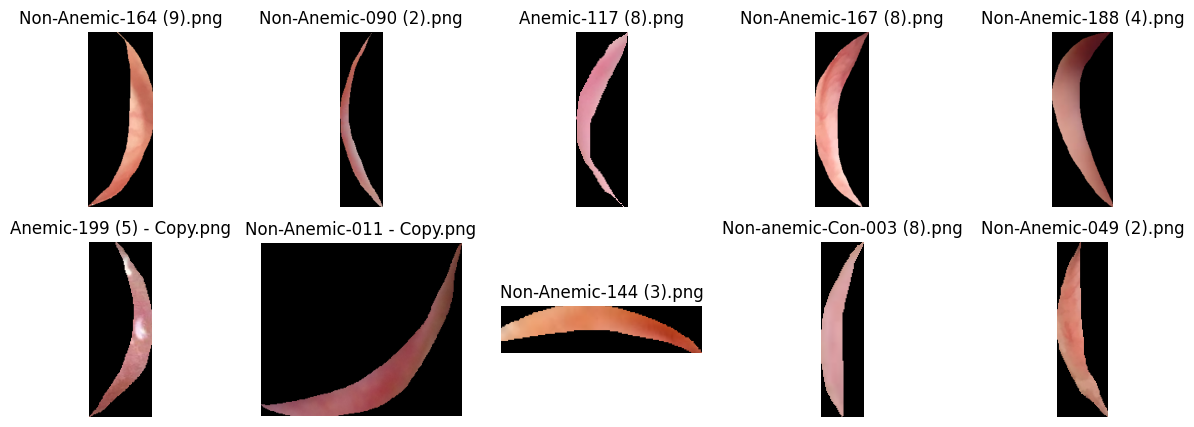

In [ ]:
def show_random_images(image_paths, n=10):
    plt.figure(figsize=(15,5))
    for i in range(n):
        img_path = np.random.choice(image_paths)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2,5,i+1)
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(os.path.basename(img_path))
    plt.show()

show_random_images(all_images, n=10)

In [ ]:
def get_label(filepath):
    filename = os.path.basename(filepath)
    if filename.startswith("Anemic"):
        return 1
    elif filename.startswith("Non-Anemic"):
        return 0
    else:
        return -1

In [ ]:
all_images = [f for f in all_images if get_label(f) != -1]
print("Images after filtering:", len(all_images))

Images after filtering: 4038


In [ ]:
train_files, temp_files = train_test_split(
    all_images,
    test_size=0.3,
    stratify=[get_label(f) for f in all_images],
    random_state=42
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.5,
    stratify=[get_label(f) for f in temp_files],
    random_state=42
)

print("Train:", len(train_files), "Val:", len(val_files), "Test:", len(test_files))#

Train: 2826 Val: 606 Test: 606


In [ ]:
class AnemiaDataset(Dataset):
    def __init__(self, files_list, transform=None):
        self.files = [f for f in files_list if get_label(f) != -1]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        label = get_label(img_path)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_tfms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [ ]:
batch_size = 64

train_dataset = AnemiaDataset(train_files, transform=train_tfms)
val_dataset   = AnemiaDataset(val_files,   transform=val_tfms)
test_dataset  = AnemiaDataset(test_files,  transform=val_tfms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

            Train  Validation  Test
label                              
Non-Anemic   1036         222   222
Anemic       1790         384   384


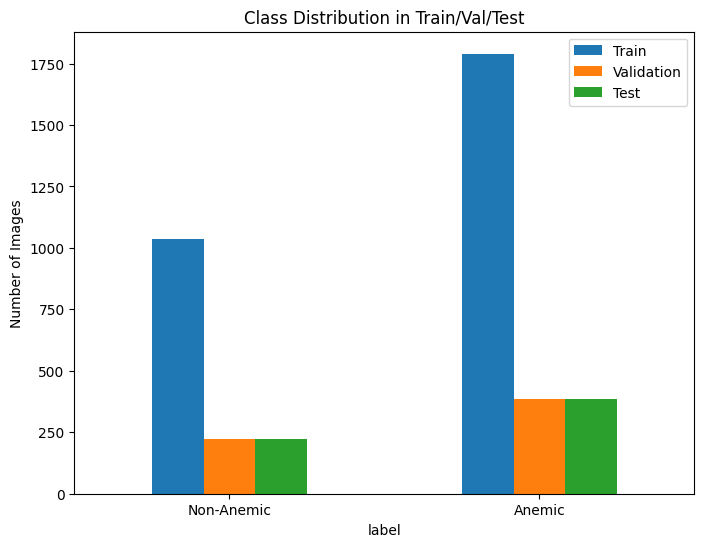

In [ ]:
def count_labels(files, split_name):
    labels = [get_label(f) for f in files]
    df = pd.DataFrame(labels, columns=["label"])
    counts = df["label"].value_counts().sort_index()
    label_map = {0: "Non-Anemic", 1: "Anemic", -1: "Unknown"}
    counts.index = counts.index.map(label_map)
    counts.name = split_name
    return counts

train_counts = count_labels(train_files, "Train")
val_counts   = count_labels(val_files, "Validation")
test_counts  = count_labels(test_files, "Test")

all_counts = pd.concat([train_counts, val_counts, test_counts], axis=1)
print(all_counts)

all_counts.plot(kind="bar", figsize=(8,6))
plt.title("Class Distribution in Train/Val/Test")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

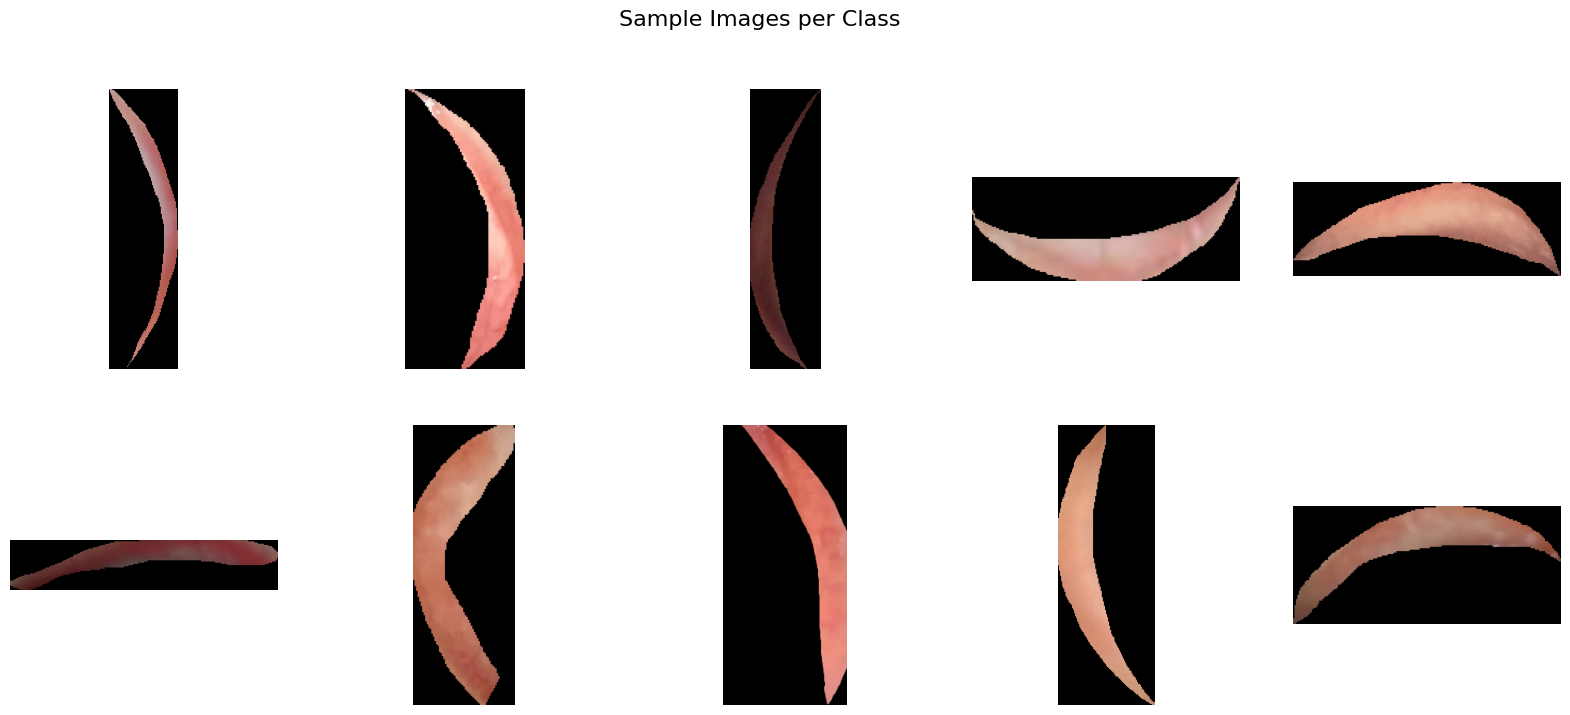

In [ ]:
def show_class_samples(files, n=3):
    classes = ["Non-Anemic", "Anemic"]
    plt.figure(figsize=(n*4, len(classes)*4))
    for i, cls in enumerate(classes):
        cls_files = [f for f in files if get_label(f) == i]
        for j in range(n):
            img_path = np.random.choice(cls_files)
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(len(classes), n, i*n + j +1)
            plt.imshow(img_rgb)
            plt.axis("off")
            if j==0:
                plt.ylabel(cls, fontsize=14)
    plt.suptitle("Sample Images per Class", fontsize=16)
    plt.show()

show_class_samples(train_files, n=5)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),

            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(DEVICE)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

EPOCHS = 40
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

In [ ]:
model.eval()
val_loss, val_correct, val_total = 0, 0, 0
with torch.no_grad():
  for inputs, labels in val_loader:
      inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
      outputs = model(inputs)
      loss = criterion(outputs, labels)

      val_loss += loss.item() * inputs.size(0)
      _, preds = torch.max(outputs, 1)
      val_correct += (preds == labels).sum().item()
      val_total += labels.size(0)

val_loss /= val_total
val_acc = val_correct / val_total
val_losses.append(val_loss)
val_accs.append(val_acc)

print(f"Epoch {epoch+1}/{EPOCHS} - "
    f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
    f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 40/40 - Train Loss: 0.1178, Train Acc: 0.9607 - Val Loss: 0.2276, Val Acc: 0.9389


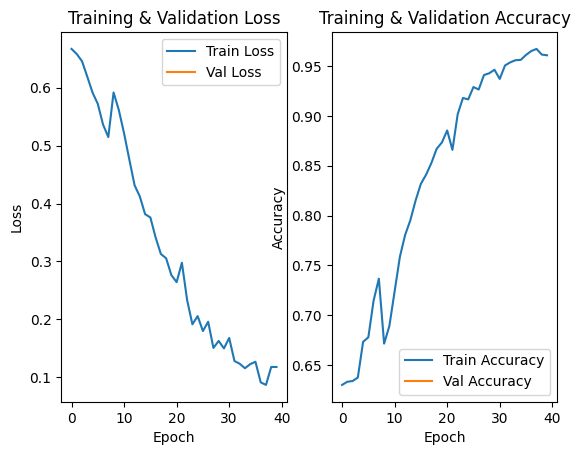

In [ ]:
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()


plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()

plt.show()
